# BiGRU + Dense + Conv + Flatten — Unified Training Pipeline with GWO

**Architecture**: Embedding → Conv1D → BatchNorm → MaxPool → BiGRU(gru//2) → BiGRU(gru) → Dense → Flatten → Output  
**Optimization**: Grey Wolf Optimizer (GWO) for hyperparameter search  


## 1. Environment & Imports

In [1]:
# ========================================
# Environment Variables
# (must be set BEFORE importing TensorFlow)
# ========================================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"]  = "2"    # suppress TF info/warning logs
os.environ["CUDA_VISIBLE_DEVICES"]  = "0"  # expose GPU 0 and 1
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"    # disable oneDNN for determinism

# ========================================
# Standard Library
# ========================================
import warnings
import random
import time
from datetime import timedelta
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings("ignore")

# ========================================
# Scientific / Data
# ========================================
import numpy as np
import pandas as pd

# ========================================
# TensorFlow / Keras
# ========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, BatchNormalization, MaxPooling1D,
    GRU, Bidirectional, Dense, Flatten, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

# ========================================
# Scikit-learn Metrics
# ========================================
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, accuracy_score
)

# ========================================
# Visualisation
# ========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ========================================
# GWO Optimiser  (mealpy >= 3.x)
# ========================================
from mealpy.swarm_based.GWO import OriginalGWO
from mealpy import FloatVar, IntegerVar

print("✓ All imports successful")
print(f"  TensorFlow : {tf.__version__}")


2026-03-26 14:34:25.894170: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-26 14:34:25.894275: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-26 14:34:25.895403: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✓ All imports successful
  TensorFlow : 2.15.0


## 2. Configuration

In [2]:
# ========================================
# Dataset Paths
# ========================================
DATA_PATHS = {
    "train": "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/train_set_balanced.xlsx",
    "test":  "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/test_set_balanced.xlsx",
    "val":   "/home/gibannn/kuliah/sem3/paper/SMILES2VEC/code/SMILES/val_set_balanced.xlsx",
}

# ========================================
# Training Hyperparameters
# ========================================
RANDOM_STATE = 116
EPOCHS       = 100
PATIENCE     = 5

BASELINE_PARAMS: Dict = {
    "learning_rate": 3e-4,
    "batch_size":    64,
    "gru_units":     64,
    "cnn_filters":   64,
    "dense_units":   32,
    "dropout":       0.3,
}

# ========================================
# GWO Configuration
# ========================================
GWO_CONFIG = {
    "pop_size": 10,
    "epoch":    10,   # total evaluations = pop_size * epoch = 100
}

# ========================================
# Output Directories & Paths
# ========================================
MODEL_NAME  = "BiGRU_Dense_Conv_Flatten"

MODEL_DIR   = "./models"
RESULTS_DIR = "./results"
PLOTS_DIR   = "./plots"
CSV_DIR     = "./csv"
IMAGE_DIR   = "./image"
GWO_DIR     = "./gwo_results"

for _dir in [MODEL_DIR, RESULTS_DIR, PLOTS_DIR, CSV_DIR, IMAGE_DIR, GWO_DIR]:
    os.makedirs(_dir, exist_ok=True)

# Convenience paths used by ModelCheckpoint
BASELINE_MODEL_PATH  = os.path.join(MODEL_DIR, f"{MODEL_NAME}_baseline.keras")
OPTIMIZED_MODEL_PATH = os.path.join(MODEL_DIR, f"{MODEL_NAME}_optimized.keras")
MODEL_IMAGE_PATH     = os.path.join(IMAGE_DIR,  f"{MODEL_NAME}_architecture.png")

print(f"✓ Configuration ready  |  Experiment: {MODEL_NAME}")
print(f"  Baseline save  → {BASELINE_MODEL_PATH}")
print(f"  Optimised save → {OPTIMIZED_MODEL_PATH}")


✓ Configuration ready  |  Experiment: BiGRU_Dense_Conv_Flatten
  Baseline save  → ./models/BiGRU_Dense_Conv_Flatten_baseline.keras
  Optimised save → ./models/BiGRU_Dense_Conv_Flatten_optimized.keras


## 3. Reproducibility & GPU Setup

In [3]:
import os
print("LD_LIBRARY_PATH:", os.environ.get('LD_LIBRARY_PATH', 'NOT SET'))
print("CUDA_VISIBLE_DEVICES:", os.environ.get('CUDA_VISIBLE_DEVICES', 'NOT SET'))

LD_LIBRARY_PATH: /home/gibannn/miniconda3/envs/SMILES/lib/python3.10/site-packages/nvidia/cublas/lib:/home/gibannn/miniconda3/envs/SMILES/lib/python3.10/site-packages/nvidia/cudnn/lib:/home/gibannn/miniconda3/envs/SMILES/lib/python3.10/site-packages/nvidia/cublas/lib:/home/gibannn/miniconda3/envs/SMILES/lib/python3.10/site-packages/nvidia/cudnn/lib:/usr/lib/wsl/lib:
CUDA_VISIBLE_DEVICES: 0


In [4]:
# ========================================
# Reproducibility
# ========================================

def set_seeds(seed: int = RANDOM_STATE) -> None:
    """Pin all random seeds for full reproducibility."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


# ========================================
# GPU Configuration
# ========================================

def setup_gpu() -> None:
    """Enable dynamic memory growth on all available GPUs."""
    gpus = tf.config.list_physical_devices("GPU")
    if not gpus:
        print("⚠  No GPU detected — running on CPU.")
        return
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical = tf.config.list_logical_devices("GPU")
        print(f"✓ GPUs: {len(gpus)} physical | {len(logical)} logical")
    except RuntimeError as e:
        print(f"⚠  GPU setup error: {e}")


set_seeds()
setup_gpu()


✓ GPUs: 1 physical | 1 logical


## 4. Data Loading

In [5]:
# ========================================
# Load Datasets  (once — reused by GWO loop)
# ========================================

def load_dataset(path: str, name: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load an Excel split and return (X, y) as int32 numpy arrays.
    Converting to numpy here avoids repeated .values calls later.
    """
    df   = pd.read_excel(path)
    X    = df.drop(columns="labels").values.astype(np.int32)
    y    = df["labels"].values.astype(np.int32)
    dist = np.bincount(y)
    print(f"{name.upper():6s}  X={X.shape}  y={y.shape}  "
          f"Label-0={dist[0]:,}  Label-1={dist[1]:,}")
    return X, y


print("Loading datasets...\n")
X_train, y_train = load_dataset(DATA_PATHS["train"], "train")
X_val,   y_val   = load_dataset(DATA_PATHS["val"],   "val")
X_test,  y_test  = load_dataset(DATA_PATHS["test"],  "test")

VOCAB_SIZE = int(max(X_train.max(), X_val.max(), X_test.max()))
MAX_LEN    = X_train.shape[1]

print(f"\n✓ Vocab size : {VOCAB_SIZE}")
print(f"✓ Seq length : {MAX_LEN}")
print("✓ Data loaded once — will be reused across baseline and GWO runs")


Loading datasets...

TRAIN   X=(8260, 271)  y=(8260,)  Label-0=4,167  Label-1=4,093
VAL     X=(1806, 271)  y=(1806,)  Label-0=893  Label-1=913
TEST    X=(1833, 271)  y=(1833,)  Label-0=893  Label-1=940

✓ Vocab size : 132
✓ Seq length : 271
✓ Data loaded once — will be reused across baseline and GWO runs


## 5. Model Architecture

In [ ]:
# ========================================
# Model Builder
# ========================================
# NOTE: The BiGRU layer order (gru_units//2 first, gru_units second) is
#       intentional and preserved from the original Notebook A design.
#       Do NOT modify without re-running the full baseline benchmark.

def build_model(
    vocab_size:   int,
    max_len:      int,
    gru_units:    int   = 64,
    cnn_filters:  int   = 64,
    dense_units:  int   = 32,
    dropout:      float = 0.3,
    seed:         int   = RANDOM_STATE,
) -> Sequential:

    set_seeds(seed)

    model = Sequential([
        Embedding(
            input_dim=vocab_size + 1,
            output_dim=128,
            input_length=max_len,
            mask_zero=False,
            name="embedding",
        ),
        Conv1D(
            filters=cnn_filters, kernel_size=5,
            padding="same", activation="relu",
            name="conv1d",
        ),
        BatchNormalization(name="batch_norm"),
        MaxPooling1D(pool_size=2, name="maxpool"),
        Bidirectional(
            GRU(gru_units // 2, return_sequences=True, dropout=dropout),
            name="bigru_1",
        ),
        Bidirectional(
            GRU(gru_units, return_sequences=False, dropout=dropout),
            name="bigru_2",
        ),
        Dense(dense_units, activation="relu", name="dense_hidden"),
        Flatten(name="flatten"),
        Dense(1, activation="sigmoid", name="output"),
    ], name=MODEL_NAME)

    return model


# ── Quick sanity-check ──────────────────────────────────────────────
_probe = build_model(VOCAB_SIZE, MAX_LEN)
_probe.build(input_shape=(None, MAX_LEN))
_probe.summary()

# Save architecture diagram
try:
    plot_model(_probe, to_file=MODEL_IMAGE_PATH, show_shapes=True, show_layer_names=True)
    print(f"\n Architecture diagram saved -> {MODEL_IMAGE_PATH}")
except Exception as _e:
    print(f"\n plot_model skipped: {_e}  (pydot / graphviz may not be installed)")

del _probe


Model: "BiGRU_Dense_Conv_Flatten"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 conv1d (Conv1D)             (None, 271, 64)           41024     
                                                                 
 batch_norm (BatchNormaliza  (None, 271, 64)           256       
 tion)                                                           
                                                                 
 maxpool (MaxPooling1D)      (None, 135, 64)           0         
                                                                 
 bigru_1 (Bidirectional)     (None, 135, 64)           18816     
                                                                 
 bigru_2 (Bidirectional)     (None, 128)               49920     
                                          

## 6. Evaluation Utilities

In [7]:
# ========================================
# ComputeMetrics  (adapted from Notebook B)
# ========================================

class ComputeMetrics:
    """Compute and expose standard binary-classification metrics."""

    def __init__(self, y_true: np.ndarray, y_pred: np.ndarray) -> None:
        self.y_true = np.asarray(y_true).flatten()
        self.y_pred = np.asarray(y_pred).flatten()

    def get_confusion_matrix(self) -> np.ndarray:
        return confusion_matrix(self.y_true, self.y_pred)

    def get_precision(self) -> float:
        return precision_score(self.y_true, self.y_pred, zero_division=0)

    def get_recall(self) -> float:
        return recall_score(self.y_true, self.y_pred, zero_division=0)

    def get_f1_score(self) -> float:
        return f1_score(self.y_true, self.y_pred, zero_division=0)

    def get_accuracy(self) -> float:
        return accuracy_score(self.y_true, self.y_pred)

    def get_all(self) -> Dict:
        cm = self.get_confusion_matrix()
        tn, fp, fn, tp = cm.ravel()
        return {
            "TP":        int(tp),
            "TN":        int(tn),
            "FP":        int(fp),
            "FN":        int(fn),
            "Accuracy":  self.get_accuracy(),
            "Precision": self.get_precision(),
            "Recall":    self.get_recall(),
            "F1-Score":  self.get_f1_score(),
        }

    def print_report(self, title: str = "Classification Report") -> None:
        print("\n" + "=" * 52)
        print(title)
        print("=" * 52)
        for k, v in self.get_all().items():
            line = f"  {k:12s}: {v:.4f}" if isinstance(v, float) else f"  {k:12s}: {v}"
            print(line)


# ========================================
# History-to-CSV helper  (from Notebook B)
# ========================================

def save_training_history(history, filepath: str) -> None:
    """Persist per-epoch training metrics to a CSV file."""
    keys = list(history.history.keys())
    df   = pd.DataFrame({"epoch": range(1, len(history.history[keys[0]]) + 1)})
    for k in keys:
        df[k] = history.history[k]
    df.to_csv(filepath, index=False)
    print(f"✓ Training history -> {filepath}")


print("✓ Evaluation utilities ready")


✓ Evaluation utilities ready


## 7. Baseline Model Training

In [8]:
# ========================================
# Baseline Training
# ========================================
# FIX (Notebook A): cell was truncated — restored with full model.fit(),
#   ModelCheckpoint, timing, and baseline metric capture.
# FIX (Notebook A): loss= argument was missing in model.compile().

print("=" * 60)
print("BASELINE MODEL TRAINING")
print("=" * 60)

# Clear any leftover graph / variable state
tf.keras.backend.clear_session()
set_seeds()

# ── Build ──────────────────────────────────────────────────────────
baseline_model = build_model(
    VOCAB_SIZE, MAX_LEN,
    gru_units   = BASELINE_PARAMS["gru_units"],
    cnn_filters = BASELINE_PARAMS["cnn_filters"],
    dense_units = BASELINE_PARAMS["dense_units"],
    dropout     = BASELINE_PARAMS["dropout"],
)

# ── Compile ────────────────────────────────────────────────────────
# FIX: loss= was absent in Notebook A; BinaryFocalCrossentropy now passed
baseline_model.compile(
    optimizer = Adam(learning_rate=BASELINE_PARAMS["learning_rate"]),
    loss      = tf.keras.losses.BinaryFocalCrossentropy(gamma=2),
    metrics   = ["accuracy", tf.keras.metrics.AUC(name="auc")],
)
baseline_model.summary()

# ── Callbacks — ModelCheckpoint saves the BEST epoch (by val_auc) ──
baseline_callbacks = [
    EarlyStopping(
        monitor="val_auc", mode="max",
        patience=PATIENCE, restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=BASELINE_MODEL_PATH,
        monitor="val_auc", mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

# ── Train ──────────────────────────────────────────────────────────
baseline_start = time.time()

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BASELINE_PARAMS["batch_size"],
    callbacks       = baseline_callbacks,
    verbose         = 1,
)

baseline_time = time.time() - baseline_start

# ── Capture validation metrics for later comparison ────────────────
_base_val_pred = (baseline_model.predict(X_val, verbose=0) > 0.5).astype(int)
_base_val_cm   = ComputeMetrics(y_val, _base_val_pred)
baseline_f1    = _base_val_cm.get_f1_score()
baseline_acc   = _base_val_cm.get_accuracy()
_base_val_cm.print_report("Baseline — Validation Set")

# ── Save history ───────────────────────────────────────────────────
save_training_history(
    baseline_history,
    os.path.join(CSV_DIR, f"{MODEL_NAME}_baseline_history.csv")
)

print(f"\n✓ Baseline training done in {str(timedelta(seconds=int(baseline_time)))}")
print(f"✓ Best model checkpoint -> {BASELINE_MODEL_PATH}")


BASELINE MODEL TRAINING
Model: "BiGRU_Dense_Conv_Flatten"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 conv1d (Conv1D)             (None, 271, 64)           41024     
                                                                 
 batch_norm (BatchNormaliza  (None, 271, 64)           256       
 tion)                                                           
                                                                 
 maxpool (MaxPooling1D)      (None, 135, 64)           0         
                                                                 
 bigru_1 (Bidirectional)     (None, 135, 64)           18816     
                                                                 
 bigru_2 (Bidirectional)     (None, 128)               49920     
                  

I0000 00:00:1774510591.244226  880100 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


130/130 [==============================] - ETA: 0s - loss: 0.0883 - accuracy: 0.8529 - auc: 0.9226
Epoch 1: val_auc improved from -inf to 0.96269, saving model to ./models/BiGRU_Dense_Conv_Flatten_baseline.keras
130/130 [==============================] - 20s 81ms/step - loss: 0.0883 - accuracy: 0.8529 - auc: 0.9226 - val_loss: 0.1254 - val_accuracy: 0.9020 - val_auc: 0.9627
Epoch 2/100
130/130 [==============================] - ETA: 0s - loss: 0.0597 - accuracy: 0.9111 - auc: 0.9593
Epoch 2: val_auc improved from 0.96269 to 0.96731, saving model to ./models/BiGRU_Dense_Conv_Flatten_baseline.keras
130/130 [==============================] - 8s 63ms/step - loss: 0.0597 - accuracy: 0.9111 - auc: 0.9593 - val_loss: 0.0864 - val_accuracy: 0.9081 - val_auc: 0.9673
Epoch 3/100
130/130 [==============================] - ETA: 0s - loss: 0.0530 - accuracy: 0.9177 - auc: 0.9677
Epoch 3: val_auc improved from 0.96731 to 0.97234, saving model to ./models/BiGRU_Dense_Conv_Flatten_baseline.keras
130/1

## 8. GWO Hyperparameter Search

In [9]:
# ========================================
# Search Space Definition
# ========================================

SEARCH_SPACE = {
    "learning_rate": (1e-5, 1e-2),
    "batch_size":    (64, 512),
    "gru_units":     (32, 128),
    "cnn_filters":   (32, 128),
    "dense_units":   (16, 64),
    "dropout":       (0.1, 0.5),
}

# mealpy 3.x variable objects
bounds = [
    FloatVar(lb=1e-5, ub=1e-2,  name="learning_rate"),
    IntegerVar(lb=64, ub=512,   name="batch_size"),
    IntegerVar(lb=32, ub=128,   name="gru_units"),
    IntegerVar(lb=32, ub=128,   name="cnn_filters"),
    IntegerVar(lb=16, ub=64,    name="dense_units"),
    FloatVar(lb=0.1,  ub=0.5,   name="dropout"),
]

print("✓ GWO search space:")
for k, (lo, hi) in SEARCH_SPACE.items():
    print(f"  {k:16s}: [{lo}, {hi}]")


✓ GWO search space:
  learning_rate   : [1e-05, 0.01]
  batch_size      : [64, 512]
  gru_units       : [32, 128]
  cnn_filters     : [32, 128]
  dense_units     : [16, 64]
  dropout         : [0.1, 0.5]


In [10]:
# ========================================
# Objective Function for GWO
# ========================================

# Module-level globals track progress across wolf evaluations
iteration_counter: int  = 0
best_f1_so_far:   float = 0.0
optimization_log: List  = []


def objective_function(solution: np.ndarray) -> float:
    """
    Evaluate one hyperparameter configuration.

    Parameters
    ----------
    solution : 1-D array  [lr, batch, gru, cnn, dense, dropout]

    Returns
    -------
    Negative validation F1-score (GWO minimises).
    """
    global iteration_counter, best_f1_so_far
    iteration_counter += 1

    # ── Decode & clamp ────────────────────────────────────────────
    lr          = float(solution[0])
    batch_size  = int(np.clip(round(solution[1]), 32,  512))
    gru_units   = int(np.clip(round(solution[2]), 16,  128))
    cnn_filters = int(np.clip(round(solution[3]), 16,  128))
    dense_units = int(np.clip(round(solution[4]),  8,   64))
    dropout     = float(solution[5])

    print(f"[Iter {iteration_counter:>3d}]  lr={lr:.2e}  bs={batch_size}  "
          f"gru={gru_units}  cnn={cnn_filters}  dense={dense_units}  drop={dropout:.3f}")

    try:
        tf.keras.backend.clear_session()
        set_seeds()

        model = build_model(
            VOCAB_SIZE, MAX_LEN,
            gru_units=gru_units, cnn_filters=cnn_filters,
            dense_units=dense_units, dropout=dropout,
        )
        model.compile(
            optimizer = Adam(learning_rate=lr),
            loss      = tf.keras.losses.BinaryFocalCrossentropy(gamma=2),
            metrics   = ["accuracy", tf.keras.metrics.AUC(name="auc")],
        )

        # Reduced epochs + tight patience to keep GWO affordable
        history = model.fit(
            X_train, y_train,
            validation_data = (X_val, y_val),
            epochs          = 30,
            batch_size      = batch_size,
            callbacks       = [EarlyStopping(monitor="val_auc", mode="max",
                                             patience=3, restore_best_weights=True,
                                             verbose=0)],
            verbose         = 0,
        )

        y_pred = (model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
        f1     = f1_score(y_val, y_pred, zero_division=0)
        acc    = accuracy_score(y_val, y_pred)

        tag = "  ← NEW BEST" if f1 > best_f1_so_far else ""
        if f1 > best_f1_so_far:
            best_f1_so_far = f1
        print(f"         F1={f1:.4f}  Acc={acc:.4f}{tag}")

        optimization_log.append({
            "iteration":     iteration_counter,
            "learning_rate": lr,
            "batch_size":    batch_size,
            "gru_units":     gru_units,
            "cnn_filters":   cnn_filters,
            "dense_units":   dense_units,
            "dropout":       dropout,
            "f1_score":      f1,
            "accuracy":      acc,
            "epochs_run":    len(history.history["loss"]),
        })

        return -f1   # GWO minimises

    except Exception as exc:
        print(f"         ERROR: {exc}")
        return 0.0


print("✓ Objective function defined")


✓ Objective function defined


In [11]:
# ========================================
# Run GWO Optimisation
# ========================================

print("\n" + "=" * 60)
print("STARTING GWO OPTIMISATION")
print("=" * 60)
print(f"  Population : {GWO_CONFIG['pop_size']}")
print(f"  Epochs     : {GWO_CONFIG['epoch']}")
print(f"  Evaluations: {GWO_CONFIG['pop_size'] * GWO_CONFIG['epoch']}")
print("=" * 60)

problem_def = {
    "obj_func": objective_function,
    "bounds":   bounds,
    "minmax":   "min",
}

# To swap to a different mealpy optimiser (e.g. PSO, WOA), replace the line
# below — everything else in the pipeline stays the same:
#   from mealpy.swarm_based.PSO import OriginalPSO
#   optimizer = OriginalPSO(epoch=..., pop_size=...)
gwo_optimizer = OriginalGWO(
    epoch    = GWO_CONFIG["epoch"],
    pop_size = GWO_CONFIG["pop_size"],
)

gwo_start     = time.time()
g_best        = gwo_optimizer.solve(problem_def)
gwo_time      = time.time() - gwo_start

best_solution = g_best.solution
best_fitness  = g_best.target.fitness   # negative F1

print("\n" + "=" * 60)
print("GWO COMPLETE")
print("=" * 60)
print(f"  Wall time   : {str(timedelta(seconds=int(gwo_time)))}")
print(f"  Best val F1 : {-best_fitness:.4f}")
print("=" * 60)


2026/03/26 02:45:55 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=10, pop_size=10)



STARTING GWO OPTIMISATION
  Population : 10
  Epochs     : 10
  Evaluations: 100
[Iter   1]  lr=5.36e-03  bs=280  gru=79  cnn=118  dense=55  drop=0.177
         F1=0.9301  Acc=0.9308  ← NEW BEST
[Iter   2]  lr=4.55e-03  bs=376  gru=48  cnn=87  dense=18  drop=0.457
         F1=0.9254  Acc=0.9297
[Iter   3]  lr=2.02e-03  bs=168  gru=68  cnn=33  dense=55  drop=0.374
         F1=0.9395  Acc=0.9402  ← NEW BEST
[Iter   4]  lr=5.51e-03  bs=195  gru=91  cnn=100  dense=28  drop=0.370
         F1=0.9261  Acc=0.9302
[Iter   5]  lr=4.84e-03  bs=463  gru=106  cnn=49  dense=60  drop=0.129
         F1=0.9286  Acc=0.9269
[Iter   6]  lr=4.94e-03  bs=223  gru=53  cnn=53  dense=22  drop=0.247
         F1=0.9341  Acc=0.9358
[Iter   7]  lr=7.48e-03  bs=270  gru=103  cnn=81  dense=21  drop=0.248
         F1=0.9326  Acc=0.9347
[Iter   8]  lr=9.39e-03  bs=278  gru=64  cnn=64  dense=64  drop=0.344
         F1=0.9362  Acc=0.9374
[Iter   9]  lr=9.01e-04  bs=331  gru=60  cnn=92  dense=44  drop=0.398
         F1=

2026/03/26 02:59:38 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: -0.9443813847900113, Global best: -0.9443813847900113, Runtime: 407.68555 seconds


         F1=0.9296  Acc=0.9286
[Iter  21]  lr=6.14e-03  bs=168  gru=128  cnn=86  dense=31  drop=0.100
         F1=0.9430  Acc=0.9435
[Iter  22]  lr=4.76e-03  bs=324  gru=100  cnn=128  dense=43  drop=0.234
         F1=0.9371  Acc=0.9391
[Iter  23]  lr=3.79e-03  bs=192  gru=35  cnn=84  dense=49  drop=0.315
         F1=0.9324  Acc=0.9347
[Iter  24]  lr=3.49e-03  bs=228  gru=55  cnn=77  dense=46  drop=0.206
         F1=0.9391  Acc=0.9408
[Iter  25]  lr=8.04e-03  bs=365  gru=81  cnn=98  dense=32  drop=0.205
         F1=0.8896  Acc=0.8782
[Iter  26]  lr=3.40e-03  bs=64  gru=104  cnn=32  dense=41  drop=0.214
         F1=0.9369  Acc=0.9374
[Iter  27]  lr=7.18e-03  bs=182  gru=93  cnn=79  dense=64  drop=0.246
         F1=0.9376  Acc=0.9391
[Iter  28]  lr=4.52e-03  bs=297  gru=67  cnn=94  dense=26  drop=0.190
         F1=0.9336  Acc=0.9369
[Iter  29]  lr=6.03e-03  bs=125  gru=84  cnn=66  dense=34  drop=0.154
         F1=0.9354  Acc=0.9380
[Iter  30]  lr=8.15e-03  bs=248  gru=128  cnn=95  dense=1

2026/03/26 03:08:22 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: -0.9443813847900113, Global best: -0.9443813847900113, Runtime: 548.23764 seconds


...

         F1=0.9229  Acc=0.9275
[Iter  91]  lr=2.92e-03  bs=283  gru=87  cnn=69  dense=47  drop=0.361
         F1=0.9326  Acc=0.9324
[Iter  92]  lr=2.59e-03  bs=255  gru=88  cnn=70  dense=45  drop=0.309
         F1=0.9389  Acc=0.9413
[Iter  93]  lr=2.67e-03  bs=281  gru=84  cnn=66  dense=47  drop=0.356
         F1=0.9281  Acc=0.9264
[Iter  94]  lr=2.89e-03  bs=258  gru=88  cnn=67  dense=48  drop=0.342
         F1=0.9287  Acc=0.9324
[Iter  95]  lr=2.89e-03  bs=266  gru=90  cnn=70  dense=45  drop=0.329
         F1=0.9304  Acc=0.9336
[Iter  96]  lr=2.69e-03  bs=326  gru=100  cnn=65  dense=47  drop=0.317
         F1=0.9326  Acc=0.9352
[Iter  97]  lr=2.72e-03  bs=274  gru=83  cnn=76  dense=44  drop=0.318
         F1=0.9096  Acc=0.9031
[Iter  98]  lr=2.53e-03  bs=255  gru=92  cnn=71  dense=45  drop=0.317
         F1=0.9328  Acc=0.9341
[Iter  99]  lr=2.75e-03  bs=268  gru=91  cnn=58  dense=46  drop=0.347
         F1=0.9373  Acc=0.9396
[Iter 100]  lr=2.25e-03  bs=283  gru=89  cnn=74  dense=44  

2026/03/26 04:04:19 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 9, Current best: -0.9452054794520548, Global best: -0.9452054794520548, Runtime: 471.81584 seconds


         F1=0.9258  Acc=0.9297
[Iter 101]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  drop=0.341
         F1=0.9000  Acc=0.9081
[Iter 102]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  drop=0.341
         F1=0.8920  Acc=0.9014
[Iter 103]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  drop=0.341
         F1=0.9300  Acc=0.9336
[Iter 104]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  drop=0.341
         F1=0.9389  Acc=0.9413
[Iter 105]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  drop=0.341
         F1=0.9375  Acc=0.9396
[Iter 106]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  drop=0.341
         F1=0.9358  Acc=0.9385
[Iter 107]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  drop=0.341
         F1=0.9313  Acc=0.9347
[Iter 108]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  drop=0.341
         F1=0.9299  Acc=0.9336
[Iter 109]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  drop=0.341
         F1=0.9344  Acc=0.9374
[Iter 110]  lr=2.65e-03  bs=276  gru=90  cnn=70  dense=47  d

2026/03/26 04:10:40 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 10, Current best: -0.9452054794520548, Global best: -0.9452054794520548, Runtime: 403.02407 seconds


         F1=0.9332  Acc=0.9363

GWO COMPLETE
  Wall time   : 1:24:45
  Best val F1 : 0.9452


In [12]:
# ========================================
# Extract & Save Best Hyperparameters
# ========================================

best_params: Dict = {
    "learning_rate": float(best_solution[0]),
    "batch_size":    int(np.clip(round(best_solution[1]), 32,  512)),
    "gru_units":     int(np.clip(round(best_solution[2]), 16,  128)),
    "cnn_filters":   int(np.clip(round(best_solution[3]), 16,  128)),
    "dense_units":   int(np.clip(round(best_solution[4]),  8,   64)),
    "dropout":       float(best_solution[5]),
}

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS FOUND BY GWO")
print("=" * 60)
for k, v in best_params.items():
    print(f"  {k:16s}: {v}")
print("=" * 60)

# Save optimisation log
log_df    = pd.DataFrame(optimization_log)
log_path  = os.path.join(GWO_DIR, f"{MODEL_NAME}_gwo_log.csv")
log_df.to_csv(log_path, index=False)
print(f"\n✓ GWO log      -> {log_path}")

# Save best params
params_path = os.path.join(GWO_DIR, f"{MODEL_NAME}_best_params.csv")
pd.DataFrame([best_params]).to_csv(params_path, index=False)
print(f"✓ Best params  -> {params_path}")



BEST HYPERPARAMETERS FOUND BY GWO
  learning_rate   : 0.0032963423865816984
  batch_size      : 285
  gru_units       : 103
  cnn_filters     : 88
  dense_units     : 46
  dropout         : 0.3186727452923584

✓ GWO log      -> ./gwo_results/BiGRU_Dense_Conv_Flatten_gwo_log.csv
✓ Best params  -> ./gwo_results/BiGRU_Dense_Conv_Flatten_best_params.csv


## 9. Final Model Training (Optimised Hyperparameters)

In [13]:
# ========================================
# Retrain with GWO Best Hyperparameters
# ========================================
# FIX (Notebook A): cell was truncated — restored with full model.fit(),
#   ModelCheckpoint, timing, and optimized_history capture.
# FIX (Notebook A): loss= argument was missing in model.compile().

print("=" * 60)
print("FINAL MODEL TRAINING — OPTIMISED HYPERPARAMETERS")
print("=" * 60)

tf.keras.backend.clear_session()
set_seeds()

# ── Build ──────────────────────────────────────────────────────────
optimized_model = build_model(
    VOCAB_SIZE, MAX_LEN,
    gru_units   = best_params["gru_units"],
    cnn_filters = best_params["cnn_filters"],
    dense_units = best_params["dense_units"],
    dropout     = best_params["dropout"],
)

# ── Compile ────────────────────────────────────────────────────────
optimized_model.compile(
    optimizer = Adam(learning_rate=best_params["learning_rate"]),
    loss      = tf.keras.losses.BinaryFocalCrossentropy(gamma=2),
    metrics   = ["accuracy", tf.keras.metrics.AUC(name="auc")],
)
optimized_model.summary()

# ── Callbacks — ModelCheckpoint saves the BEST epoch (by val_auc) ──
optimized_callbacks = [
    EarlyStopping(
        monitor="val_auc", mode="max",
        patience=PATIENCE, restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=OPTIMIZED_MODEL_PATH,
        monitor="val_auc", mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

# ── Train (full epoch budget) ──────────────────────────────────────
optimized_start = time.time()

optimized_history = optimized_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = best_params["batch_size"],
    callbacks       = optimized_callbacks,
    verbose         = 1,
)

optimized_time = time.time() - optimized_start

# ── Capture validation metrics ─────────────────────────────────────
_opt_val_pred = (optimized_model.predict(X_val, verbose=0) > 0.5).astype(int)
_opt_val_cm   = ComputeMetrics(y_val, _opt_val_pred)
opt_val_f1    = _opt_val_cm.get_f1_score()
opt_val_acc   = _opt_val_cm.get_accuracy()
_opt_val_cm.print_report("Optimised — Validation Set")

# ── Save history ───────────────────────────────────────────────────
save_training_history(
    optimized_history,
    os.path.join(CSV_DIR, f"{MODEL_NAME}_optimized_history.csv")
)

print(f"\n✓ Optimised training done in {str(timedelta(seconds=int(optimized_time)))}")
print(f"✓ Best model checkpoint -> {OPTIMIZED_MODEL_PATH}")


FINAL MODEL TRAINING — OPTIMISED HYPERPARAMETERS
Model: "BiGRU_Dense_Conv_Flatten"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 271, 128)          17024     
                                                                 
 conv1d (Conv1D)             (None, 271, 88)           56408     
                                                                 
 batch_norm (BatchNormaliza  (None, 271, 88)           352       
 tion)                                                           
                                                                 
 maxpool (MaxPooling1D)      (None, 135, 88)           0         
                                                                 
 bigru_1 (Bidirectional)     (None, 135, 102)          43146     
                                                                 
 bigru_2 (Bidirectional)     (None, 206)               1279

## 10. Evaluation & Comparison

In [14]:
# ========================================
# Evaluate Both Models on Test Set
# ========================================

print("Running predictions on test set...\n")

# ── Baseline ──────────────────────────────────────────────────────
base_pred = (baseline_model.predict(X_test, verbose=0) > 0.5).astype(int)
base_cm   = ComputeMetrics(y_test, base_pred)
base_cm.print_report("Baseline Model — Test Set")

# ── Optimised ─────────────────────────────────────────────────────
opt_pred  = (optimized_model.predict(X_test, verbose=0) > 0.5).astype(int)
opt_cm    = ComputeMetrics(y_test, opt_pred)
opt_cm.print_report("GWO-Optimised Model — Test Set")


Running predictions on test set...


Baseline Model — Test Set
  TP          : 871
  TN          : 869
  FP          : 24
  FN          : 69
  Accuracy    : 0.9493
  Precision   : 0.9732
  Recall      : 0.9266
  F1-Score    : 0.9493

GWO-Optimised Model — Test Set
  TP          : 858
  TN          : 876
  FP          : 17
  FN          : 82
  Accuracy    : 0.9460
  Precision   : 0.9806
  Recall      : 0.9128
  F1-Score    : 0.9455


In [15]:
# ========================================
# Side-by-Side Comparison Table
# ========================================

base_metrics = base_cm.get_all()
opt_metrics  = opt_cm.get_all()

comparison = pd.DataFrame([
    {
        "Model":          "Baseline",
        "Learning_Rate":  BASELINE_PARAMS["learning_rate"],
        "Batch_Size":     BASELINE_PARAMS["batch_size"],
        "GRU_Units":      BASELINE_PARAMS["gru_units"],
        "CNN_Filters":    BASELINE_PARAMS["cnn_filters"],
        "Dense_Units":    BASELINE_PARAMS["dense_units"],
        "Dropout":        BASELINE_PARAMS["dropout"],
        "Val_F1":         round(baseline_f1,  4),
        "Val_Acc":        round(baseline_acc, 4),
        "Test_F1":        round(base_metrics["F1-Score"],  4),
        "Test_Acc":       round(base_metrics["Accuracy"],  4),
        "Test_Precision": round(base_metrics["Precision"], 4),
        "Test_Recall":    round(base_metrics["Recall"],    4),
        "Training_Time":  str(timedelta(seconds=int(baseline_time))),
    },
    {
        "Model":          "GWO-Optimised",
        "Learning_Rate":  best_params["learning_rate"],
        "Batch_Size":     best_params["batch_size"],
        "GRU_Units":      best_params["gru_units"],
        "CNN_Filters":    best_params["cnn_filters"],
        "Dense_Units":    best_params["dense_units"],
        "Dropout":        best_params["dropout"],
        "Val_F1":         round(opt_val_f1,  4),
        "Val_Acc":        round(opt_val_acc, 4),
        "Test_F1":        round(opt_metrics["F1-Score"],  4),
        "Test_Acc":       round(opt_metrics["Accuracy"],  4),
        "Test_Precision": round(opt_metrics["Precision"], 4),
        "Test_Recall":    round(opt_metrics["Recall"],    4),
        "Training_Time":  str(timedelta(seconds=int(optimized_time))),
    },
])

f1_delta  = opt_metrics["F1-Score"]  - base_metrics["F1-Score"]
acc_delta = opt_metrics["Accuracy"]  - base_metrics["Accuracy"]

print("\n" + "=" * 120)
print("BASELINE vs GWO-OPTIMISED")
print("=" * 120)
print(comparison.to_string(index=False))
print("\n" + "-" * 40)
print(f"  Delta F1-Score (test) : {f1_delta:+.4f}")
print(f"  Delta Accuracy (test) : {acc_delta:+.4f}")
print("=" * 120)

cmp_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_comparison.csv")
comparison.to_csv(cmp_path, index=False)
print(f"\n✓ Comparison table -> {cmp_path}")



BASELINE vs GWO-OPTIMISED
        Model  Learning_Rate  Batch_Size  GRU_Units  CNN_Filters  Dense_Units  Dropout  Val_F1  Val_Acc  Test_F1  Test_Acc  Test_Precision  Test_Recall Training_Time
     Baseline       0.000300          64         64           64           32 0.300000  0.9393   0.9402   0.9493    0.9493          0.9732       0.9266       0:04:42
GWO-Optimised       0.003296         285        103           88           46 0.318673  0.9386   0.9402   0.9455    0.9460          0.9806       0.9128       0:00:58

----------------------------------------
  Delta F1-Score (test) : -0.0039
  Delta Accuracy (test) : -0.0033

✓ Comparison table -> ./results/BiGRU_Dense_Conv_Flatten_comparison.csv


## 11. Visualisation

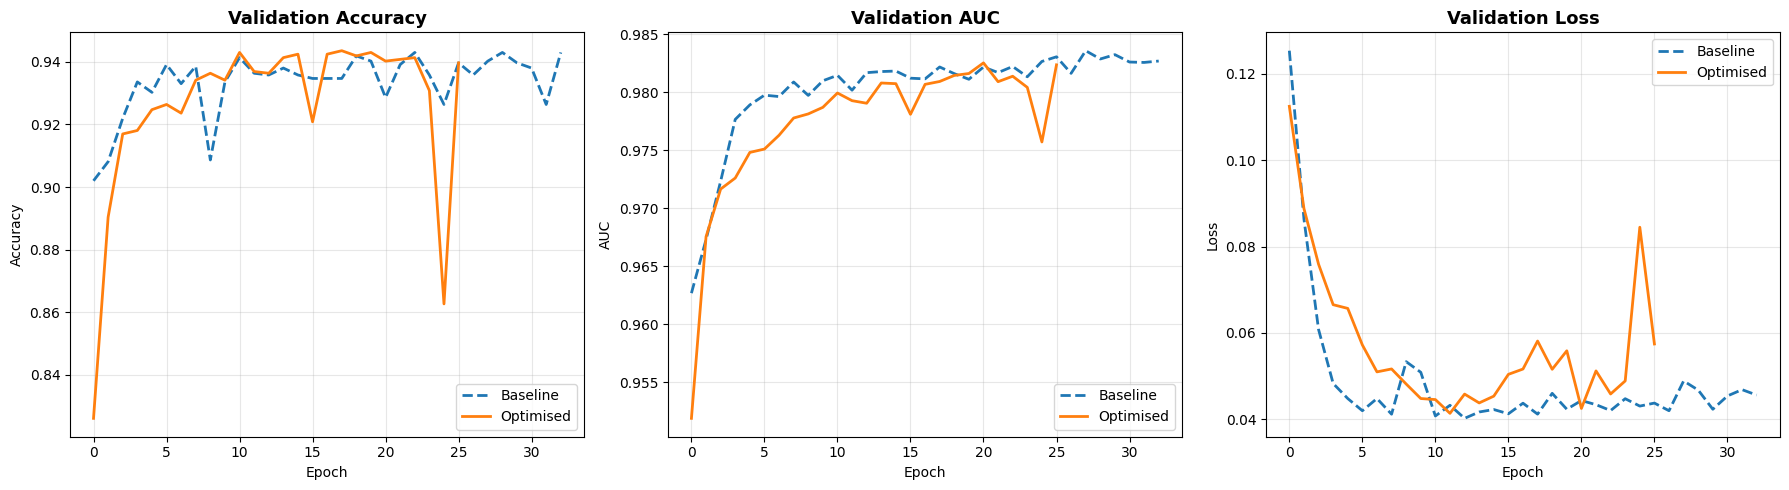

✓ Training curves -> ./plots/BiGRU_Dense_Conv_Flatten_training_comparison.png


In [16]:
# ========================================
# Training History (Accuracy, AUC, Loss)
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

_plot_kw = {"lw": 2}

for ax, metric, ylabel, title in zip(
    axes,
    ["val_accuracy", "val_auc", "val_loss"],
    ["Accuracy", "AUC", "Loss"],
    ["Validation Accuracy", "Validation AUC", "Validation Loss"],
):
    ax.plot(baseline_history.history[metric],  label="Baseline",   ls="--", **_plot_kw)
    ax.plot(optimized_history.history[metric], label="Optimised",  **_plot_kw)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
_p = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_training_comparison.png")
plt.savefig(_p, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Training curves -> {_p}")


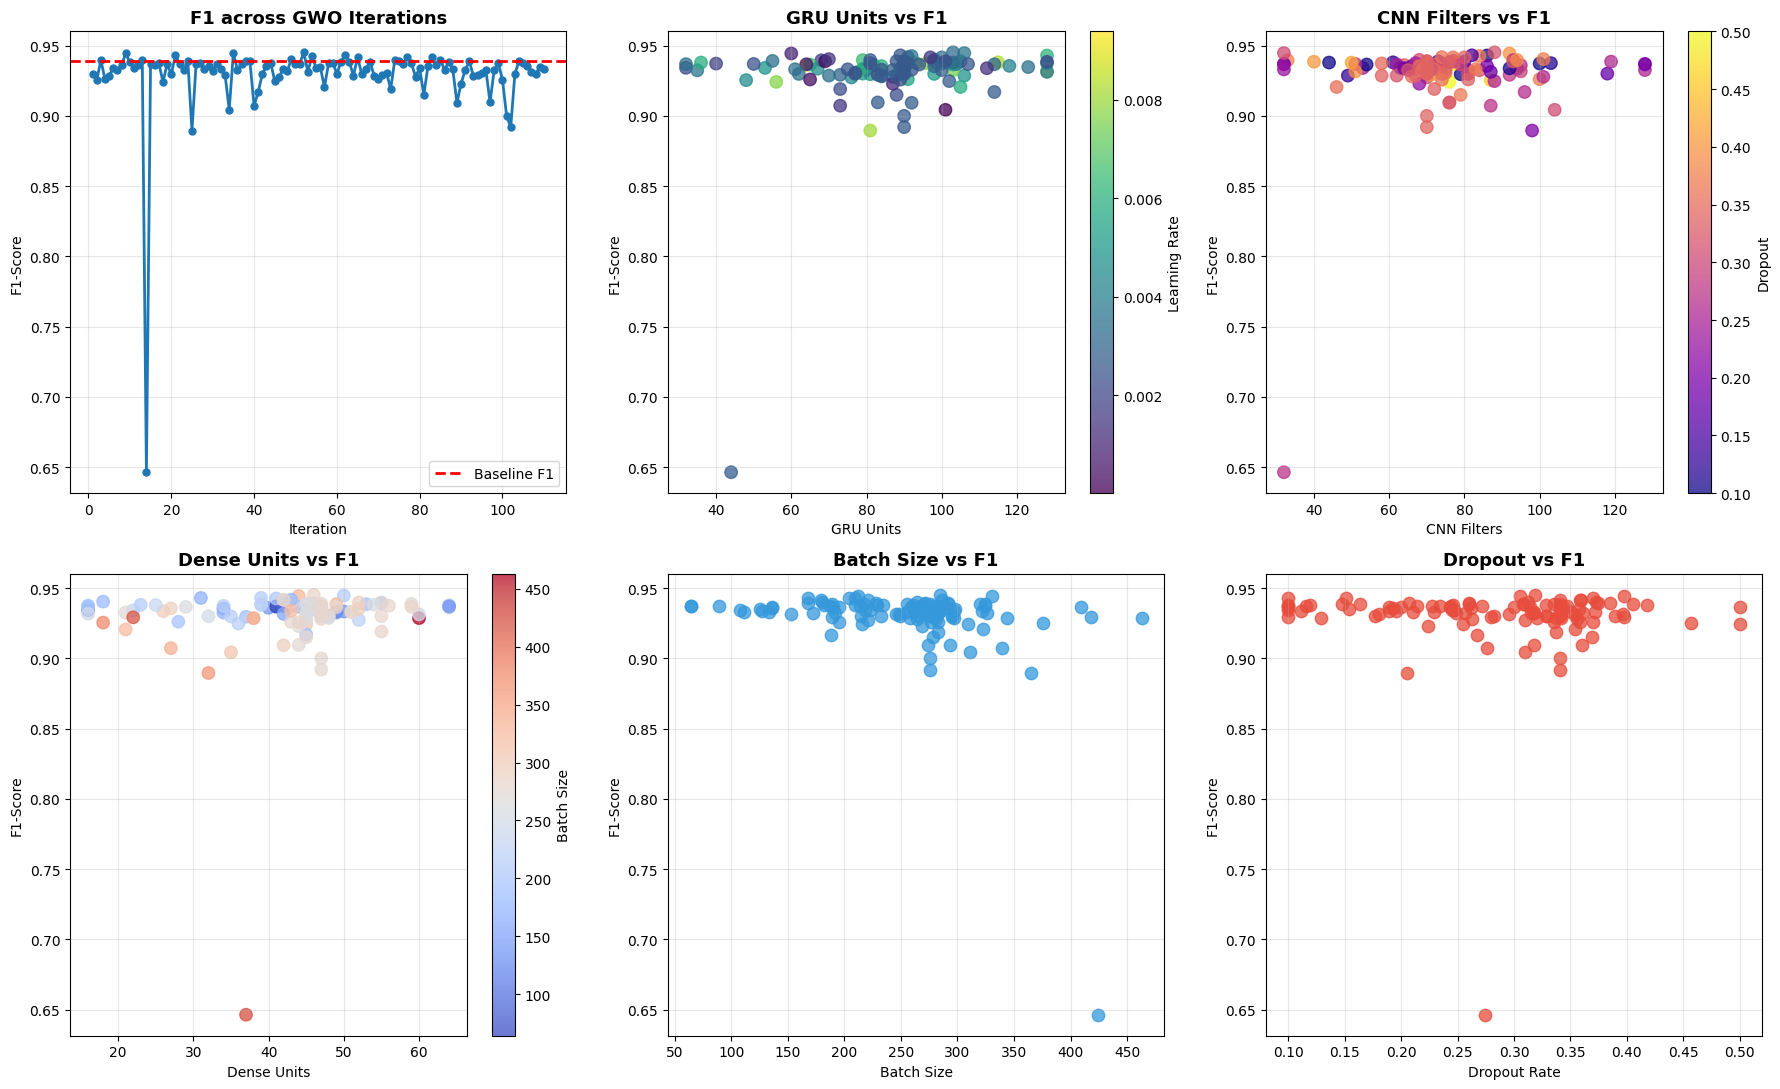

✓ GWO progress plot -> ./plots/BiGRU_Dense_Conv_Flatten_gwo_progress.png


In [17]:
# ========================================
# GWO Optimisation Progress (6-panel)
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# F1 progression
axes[0, 0].plot(log_df["iteration"], log_df["f1_score"], marker="o", lw=2, ms=5)
axes[0, 0].axhline(y=baseline_f1, color="r", ls="--", lw=2, label="Baseline F1")
axes[0, 0].set_title("F1 across GWO Iterations", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Iteration"); axes[0, 0].set_ylabel("F1-Score")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

_sc_kw = dict(s=80, alpha=0.75)

sc1 = axes[0, 1].scatter(log_df["gru_units"], log_df["f1_score"],
                          c=log_df["learning_rate"], cmap="viridis", **_sc_kw)
plt.colorbar(sc1, ax=axes[0, 1], label="Learning Rate")
axes[0, 1].set_title("GRU Units vs F1", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("GRU Units"); axes[0, 1].set_ylabel("F1-Score"); axes[0, 1].grid(alpha=0.3)

sc2 = axes[0, 2].scatter(log_df["cnn_filters"], log_df["f1_score"],
                          c=log_df["dropout"], cmap="plasma", **_sc_kw)
plt.colorbar(sc2, ax=axes[0, 2], label="Dropout")
axes[0, 2].set_title("CNN Filters vs F1", fontsize=13, fontweight="bold")
axes[0, 2].set_xlabel("CNN Filters"); axes[0, 2].set_ylabel("F1-Score"); axes[0, 2].grid(alpha=0.3)

sc3 = axes[1, 0].scatter(log_df["dense_units"], log_df["f1_score"],
                          c=log_df["batch_size"], cmap="coolwarm", **_sc_kw)
plt.colorbar(sc3, ax=axes[1, 0], label="Batch Size")
axes[1, 0].set_title("Dense Units vs F1", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Dense Units"); axes[1, 0].set_ylabel("F1-Score"); axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(log_df["batch_size"], log_df["f1_score"], color="#3498db", **_sc_kw)
axes[1, 1].set_title("Batch Size vs F1", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Batch Size"); axes[1, 1].set_ylabel("F1-Score"); axes[1, 1].grid(alpha=0.3)

axes[1, 2].scatter(log_df["dropout"], log_df["f1_score"], color="#e74c3c", **_sc_kw)
axes[1, 2].set_title("Dropout vs F1", fontsize=13, fontweight="bold")
axes[1, 2].set_xlabel("Dropout Rate"); axes[1, 2].set_ylabel("F1-Score"); axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
_p = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_gwo_progress.png")
plt.savefig(_p, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ GWO progress plot -> {_p}")


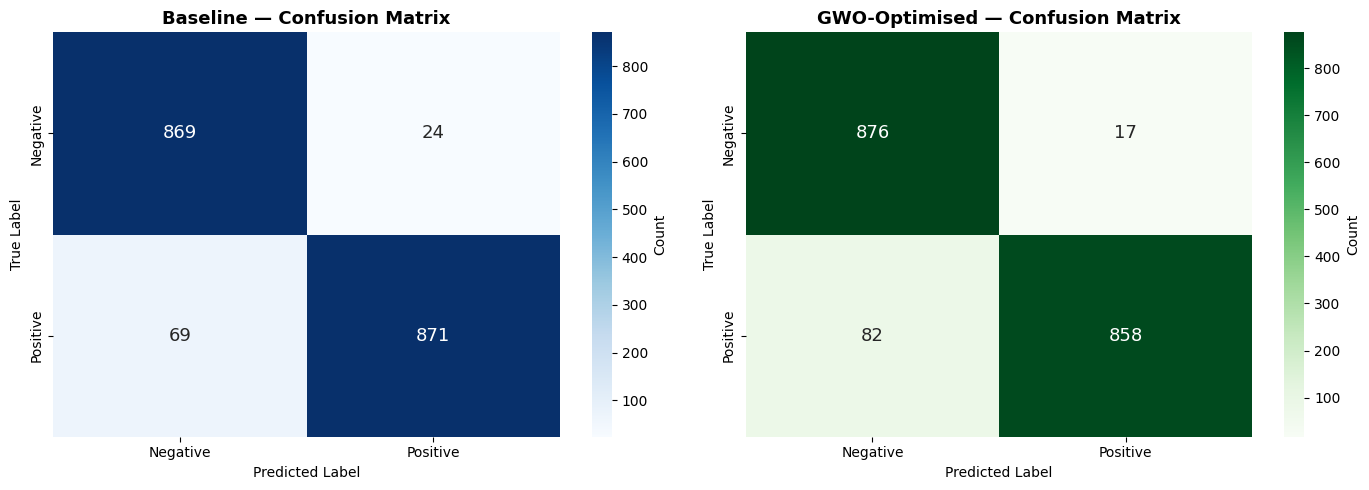

✓ Confusion matrices -> ./plots/BiGRU_Dense_Conv_Flatten_confusion_comparison.png


In [18]:
# ========================================
# Confusion Matrices (side-by-side)
# ========================================

cm_base = base_cm.get_confusion_matrix()
cm_opt  = opt_cm.get_confusion_matrix()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_hm_kw = dict(
    annot=True, fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    cbar_kws={"label": "Count"},
    annot_kws={"size": 13},
)

sns.heatmap(cm_base, cmap="Blues",  ax=axes[0], **_hm_kw)
axes[0].set_title("Baseline — Confusion Matrix", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted Label"); axes[0].set_ylabel("True Label")

sns.heatmap(cm_opt,  cmap="Greens", ax=axes[1], **_hm_kw)
axes[1].set_title("GWO-Optimised — Confusion Matrix", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted Label"); axes[1].set_ylabel("True Label")

plt.tight_layout()
_p = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_confusion_comparison.png")
plt.savefig(_p, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Confusion matrices -> {_p}")


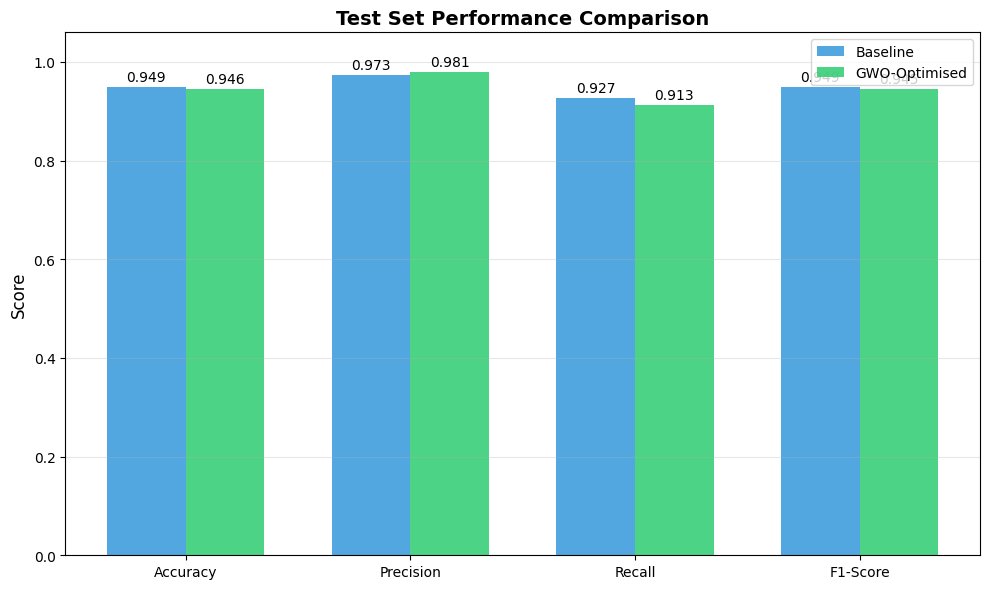

✓ Metrics bar chart -> ./plots/BiGRU_Dense_Conv_Flatten_metrics_comparison.png


In [19]:
# ========================================
# Metrics Bar Chart
# ========================================

metric_keys  = ["Accuracy", "Precision", "Recall", "F1-Score"]
base_scores  = [base_metrics[k] for k in metric_keys]
opt_scores   = [opt_metrics[k]  for k in metric_keys]

x     = np.arange(len(metric_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, base_scores, width, label="Baseline",      color="#3498db", alpha=0.85)
bars2 = ax.bar(x + width/2, opt_scores,  width, label="GWO-Optimised", color="#2ecc71", alpha=0.85)

ax.set_title("Test Set Performance Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Score", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(metric_keys)
ax.set_ylim([0, 1.06])
ax.legend(); ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.006,
                f"{h:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
_p = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_metrics_comparison.png")
plt.savefig(_p, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Metrics bar chart -> {_p}")
